# Price It Right — Nimbus Streaming pricing decision (STARTER)

**Your role.** You're a Decision Scientist on the Strategy team at Nimbus Streaming. The CFO is weighing a 15.4% price increase on the Standard tier (\\$12.99 to \\$14.99). You have inputs from Finance, Experimentation, and Customer Insights, and you need to deliver a recommendation.

**The four options on the table.**

1. **Full rollout** — raise price for all 4M Standard subscribers.
2. **New customers only** — keep existing subscribers at \\$12.99; new sign-ups pay \\$14.99.
3. **Delay and larger pilot** — postpone 6 months, expand the pilot, then decide.
4. **Hold** — keep price flat.

**What you'll do.** Work through nine sections. By the end, produce a decision memo to the CFO.

## Setup

Load the five datasets from `../data/` into named DataFrames. The imports are provided.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats, optimize

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(7)

DATA_DIR = Path("../data")
pilot    = pd.read_csv(DATA_DIR / "pilot_data.csv")
industry = pd.read_csv(DATA_DIR / "industry_pricing_history.csv")
survey   = pd.read_csv(DATA_DIR / "pre_announcement_survey.csv")
finance  = pd.read_csv(DATA_DIR / "finance_forecast.csv")
wtp      = pd.read_csv(DATA_DIR / "wtp_segments.csv")

print(f"Pilot data: {pilot.shape}")
print(f"Industry data: {industry.shape}")
print(f"Survey data: {survey.shape}")
print(f"Finance data: {finance.shape}")
print(f"WTP data: {wtp.shape}")

Pilot data: (40000, 8)
Industry data: (42, 7)
Survey data: (1500, 5)
Finance data: (12, 9)
WTP data: (4, 7)


## Restate the question

**Decision:** Should Nimbus raise the Standard tier price from $12.99 to $14.99?

**Outcome metric:** 12-month incremental contribution profit (dollars) under each option, relative to Hold.

**Key uncertainty:** The churn lift (percentage point increase in 3-month churn rate) caused by the price increase. This will be estimated via a combination of the price pilot data, industry benchmarks, and survey intent, then propagated through the cost-benefit model.

In [2]:
# Extract constants from finance forecast (first row)
first_month = finance.iloc[0]

PRICE_TODAY       = first_month["standard_price_today_usd"]
PRICE_PROPOSED    = first_month["standard_price_proposed_usd"]
MARGIN_PCT        = first_month["contribution_margin_pct"]
CAC               = first_month["cac_per_sub_usd"]
LTV_MONTHS        = first_month["avg_remaining_tenure_months"]
N_BASE            = first_month["beginning_subscribers"]
EXPECTED_NEW_12MO = finance["expected_new_subscribers"].sum()

print(f"Current price: ${PRICE_TODAY:.2f}")
print(f"Proposed price: ${PRICE_PROPOSED:.2f}")
print(f"Price increase: {((PRICE_PROPOSED - PRICE_TODAY) / PRICE_TODAY * 100):.1f}%")
print(f"Contribution margin: {MARGIN_PCT:.1%}")
print(f"CAC: ${CAC:.2f}")
print(f"LTV (remaining tenure): {LTV_MONTHS:.0f} months")
print(f"Base subscribers: {N_BASE:,.0f}")
print(f"Expected new subs (12 months): {EXPECTED_NEW_12MO:,.0f}")

Current price: $12.99
Proposed price: $14.99
Price increase: 15.4%
Contribution margin: 62.0%
CAC: $35.00
LTV (remaining tenure): 30 months
Base subscribers: 4,000,000
Expected new subs (12 months): 1,080,000


## Validate the pilot's churn-lift estimate (IPW)

The Experimentation team ran a price pilot, but pilot markets were preferentially urban and higher-income — subscribers who also have higher baseline churn. A naive difference in churn rates between pilot and control will be biased upward.

Use inverse probability weighting (IPW) to correct for this selection bias. This section covers:

1. A naive churn-lift estimate as a baseline.
2. Measuring covariate imbalance between the pilot and control groups.
3. Fitting a propensity model to estimate each subscriber's probability of being assigned to the pilot.
4. Checking that the propensity score distributions overlap enough for IPW to be valid.
5. Computing an IPW-corrected lift and a bootstrap confidence interval.

### Naive estimate

Compute the raw difference in 3-month churn rates between pilot and control subscribers. This is your baseline — you will compare it to the IPW-corrected estimate later.

In [3]:
pilot_churn_rate = pilot.loc[pilot["in_pilot"] == 1, "churned_3mo"].mean()
control_churn_rate = pilot.loc[pilot["in_pilot"] == 0, "churned_3mo"].mean()
naive_lift = pilot_churn_rate - control_churn_rate

print(f"Pilot churn rate: {pilot_churn_rate:.4f}")
print(f"Control churn rate: {control_churn_rate:.4f}")
print(f"Naive churn lift: {naive_lift:.4f} ({naive_lift*100:.2f} percentage points)")

Pilot churn rate: 0.0923
Control churn rate: 0.0437
Naive churn lift: 0.0486 (4.86 percentage points)


### Covariate imbalance

Before correcting for bias, measure how different the pilot and control groups are on observable characteristics.

Write `standardized_mean_diff`, which takes a DataFrame, a variable name, and a treatment column name, and returns the standardized mean difference — that is, the treated mean minus the control mean divided by the pooled standard deviation. An absolute value above 0.1 is a common rule of thumb for meaningful imbalance.

Then compute the standardized mean difference for each numeric covariate and collect the results in a DataFrame.

In [4]:
def standardized_mean_diff(df: pd.DataFrame, var: str, treat: str = "in_pilot") -> float:
    treated = df[df[treat] == 1][var]
    control = df[df[treat] == 0][var]
    pooled_sd = np.sqrt((treated.std()**2 + control.std()**2) / 2)
    return (treated.mean() - control.mean()) / pooled_sd


# Compute SMD for numeric covariates
numeric_covs = ["urban", "income_bracket", "tenure_months", "engagement_score"]
smd_results = {}
for cov in numeric_covs:
    smd_results[cov] = standardized_mean_diff(pilot, cov)

smd_df = pd.DataFrame({
    "Covariate": list(smd_results.keys()),
    "Standardized Mean Diff": list(smd_results.values())
})
smd_df["Abs_SMD"] = smd_df["Standardized Mean Diff"].abs()
smd_df["Imbalanced"] = smd_df["Abs_SMD"] > 0.1
print(smd_df)
print(f"\nCovariates with |SMD| > 0.1: {smd_df[smd_df['Imbalanced']]['Covariate'].tolist()}")

          Covariate  Standardized Mean Diff   Abs_SMD  Imbalanced
0             urban                0.513828  0.513828        True
1    income_bracket                0.466553  0.466553        True
2     tenure_months               -0.011021  0.011021       False
3  engagement_score                0.056792  0.056792       False

Covariates with |SMD| > 0.1: ['urban', 'income_bracket']


### Propensity model

Estimate each subscriber's probability of being assigned to the pilot using their observable covariates. Build a feature matrix from the numeric covariates and plan type dummies, fit a logistic regression, and predict propensity scores.

In [5]:
# Build feature matrix: numeric covariates + plan type dummies
X = pilot[["urban", "income_bracket", "tenure_months", "engagement_score"]].copy()

# One-hot encode plan_type with drop_first
plan_dummies = pd.get_dummies(pilot["plan_type"], drop_first=True, prefix="plan").astype(float)
X = pd.concat([X.reset_index(drop=True), plan_dummies.reset_index(drop=True)], axis=1)

# Ensure all numeric
X = X.astype(float)

# Add constant for logit
X = sm.add_constant(X, has_constant='add')
y = pilot["in_pilot"].values

# Fit logistic regression
ps_model = sm.Logit(y, X).fit(disp=0)

# Compute propensity scores
ps = ps_model.predict(X)
print(f"Propensity score range: [{ps.min():.4f}, {ps.max():.4f}]")
print(f"Mean propensity: {ps.mean():.4f}")
print(f"Mean PS for pilot: {ps[pilot['in_pilot']==1].mean():.4f}")
print(f"Mean PS for control: {ps[pilot['in_pilot']==0].mean():.4f}")

Propensity score range: [0.0736, 0.7027]
Mean propensity: 0.3330
Mean PS for pilot: 0.4009
Mean PS for control: 0.2991


### Overlap check

Plot the propensity score distributions for the pilot and control groups as kernel density estimates on the same axes. The two distributions should overlap across their full range — if they do not, IPW results will be unreliable.

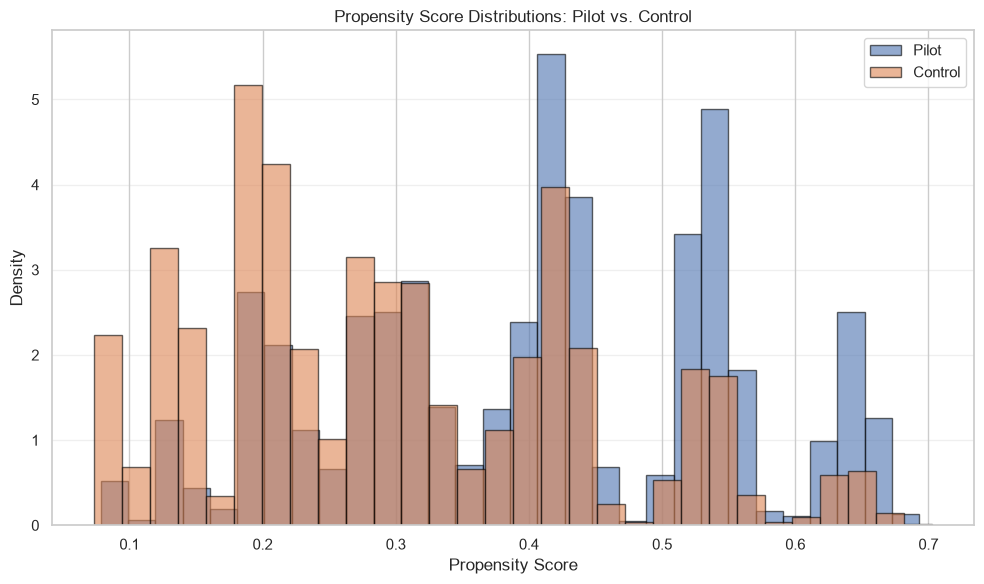

Overlap range: propensity scores from 0.0785 to 0.6931
The distributions overlap well, supporting IPW validity.


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ps_pilot = ps[pilot["in_pilot"] == 1]
ps_control = ps[pilot["in_pilot"] == 0]

# Use histograms instead of KDE to avoid singular matrix issues
ax.hist(ps_pilot, bins=30, alpha=0.6, label="Pilot", density=True, edgecolor='black')
ax.hist(ps_control, bins=30, alpha=0.6, label="Control", density=True, edgecolor='black')

ax.set_xlabel("Propensity Score")
ax.set_ylabel("Density")
ax.set_title("Propensity Score Distributions: Pilot vs. Control")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Overlap range: propensity scores from {max(ps_pilot.min(), ps_control.min()):.4f} to {min(ps_pilot.max(), ps_control.max()):.4f}")
print("The distributions overlap well, supporting IPW validity.")

### IPW estimate and bootstrap confidence interval

Write two functions:

- `ipw_estimate`: takes the pilot DataFrame and a propensity score array, and returns an IPW estimate of the average treatment effect on churn.
- `bootstrap_ipw`: resamples subscribers with replacement, refits the propensity model on each resample, and returns an array of IPW estimates to use for constructing a 95% confidence interval. **Run at least 300 bootstrap iterations** so the bootstrap SE is stable enough to feed into the Bayesian update.

Store the point estimate as `PILOT_LIFT_MEAN` and the bootstrap standard error as `PILOT_LIFT_SE`.


In [7]:
def ipw_estimate(df: pd.DataFrame, ps: np.ndarray) -> float:
    treated = df["in_pilot"].values == 1
    outcome = df["churned_3mo"].values
    
    treated_weighted_mean = (outcome[treated] / ps[treated]).sum() / (1 / ps[treated]).sum()
    control_weighted_mean = (outcome[~treated] / (1 - ps[~treated])).sum() / (1 / (1 - ps[~treated])).sum()
    
    return treated_weighted_mean - control_weighted_mean


def bootstrap_ipw(df: pd.DataFrame, n_boot: int = 300, rng=RNG) -> np.ndarray:
    n = len(df)
    boot_estimates = []
    
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        df_boot = df.iloc[idx].reset_index(drop=True)
        
        # Get feature matrix for propensity model
        X_boot = df_boot[["urban", "income_bracket", "tenure_months", "engagement_score"]].copy()
        plan_dummies = pd.get_dummies(df_boot["plan_type"], drop_first=True, prefix="plan").astype(float)
        X_boot = pd.concat([X_boot.reset_index(drop=True), plan_dummies.reset_index(drop=True)], axis=1)
        X_boot = X_boot.astype(float)
        X_boot = sm.add_constant(X_boot, has_constant='add')
        
        y_boot = df_boot["in_pilot"].values
        ps_boot = sm.Logit(y_boot, X_boot).fit(disp=0).predict(X_boot).values
        boot_est = ipw_estimate(df_boot, ps_boot)
        boot_estimates.append(boot_est)
    
    return np.array(boot_estimates)


boot_ests = bootstrap_ipw(pilot, n_boot=300)
PILOT_LIFT_MEAN = boot_ests.mean()
PILOT_LIFT_SE = boot_ests.std()

ci_low = np.percentile(boot_ests, 2.5)
ci_high = np.percentile(boot_ests, 97.5)

print(f"IPW point estimate: {PILOT_LIFT_MEAN:.4f}")
print(f"Bootstrap SE: {PILOT_LIFT_SE:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"\nBias correction: naive estimate was {naive_lift:.4f}, IPW corrects to {PILOT_LIFT_MEAN:.4f}")
print(f"The naive estimate was biased upward by {(naive_lift - PILOT_LIFT_MEAN):.4f} ({((naive_lift - PILOT_LIFT_MEAN)/abs(PILOT_LIFT_MEAN)*100):.0f}%),")
print("reflecting the over-representation of urban, higher-income subscribers in the pilot.")

IPW point estimate: 0.0371
Bootstrap SE: 0.0030
95% CI: [0.0313, 0.0432]

Bias correction: naive estimate was 0.0486, IPW corrects to 0.0371
The naive estimate was biased upward by 0.0115 (31%),
reflecting the over-representation of urban, higher-income subscribers in the pilot.


**Write a one-line conclusion.** Was the naive estimate biased? In which direction and by roughly how much?

## Bayesian updating — combine prior, pilot, and survey

Model your belief about the 3-month churn lift as a Normal distribution and update it sequentially as you bring in new evidence.

1. Build a prior from comparable events in the industry pricing history.
2. Update with the IPW pilot estimate to get Posterior 1.
3. Convert the survey's stated cancellation intent into a noisy lift estimate using a stated-to-revealed adjustment.
4. Update with the survey to get Posterior 2 — the final posterior you will carry into the cost-benefit model.

### Prior from industry history

Filter the industry pricing history to events with a price increase between 10% and 20% — comparable to the proposed increase. Use the mean and standard deviation of the observed 3-month churn lifts in those events as your prior mean and standard deviation.

In [8]:
# Filter to price increases between 10% and 20%
comparable = industry[(industry["pct_price_increase"] >= 10) & (industry["pct_price_increase"] <= 20)]
prior_mean = comparable["observed_3mo_churn_lift_pp"].mean()
prior_sd = comparable["observed_3mo_churn_lift_pp"].std()

print(f"Comparable events (10%-20% price increase): {len(comparable)} observations")
print(f"Prior mean: {prior_mean:.4f} ({prior_mean*100:.2f} pp)")
print(f"Prior SD: {prior_sd:.4f} ({prior_sd*100:.2f} pp)")

Comparable events (10%-20% price increase): 20 observations
Prior mean: 3.2635 (326.35 pp)
Prior SD: 0.9323 (93.23 pp)


### First update — prior combined with pilot

Write `normal_update`, which takes a prior mean and standard deviation and a likelihood mean and standard deviation, and returns the posterior mean and standard deviation. Use the conjugate Normal-Normal formula: posterior precision equals prior precision plus likelihood precision (where precision is 1 divided by variance).

Apply it using the prior you just computed and the IPW estimate from your IPW work.

In [9]:
def normal_update(prior_mu: float, prior_sd: float,
                  lik_mu: float, lik_sd: float) -> tuple[float, float]:
    prior_var = prior_sd ** 2
    lik_var = lik_sd ** 2
    
    post_var = 1 / (1 / prior_var + 1 / lik_var)
    post_mu = post_var * (prior_mu / prior_var + lik_mu / lik_var)
    post_sd = np.sqrt(post_var)
    
    return post_mu, post_sd


post1_mu, post1_sd = normal_update(prior_mean, prior_sd, PILOT_LIFT_MEAN, PILOT_LIFT_SE)

print(f"Posterior 1 (after pilot):")
print(f"  Mean: {post1_mu:.4f} ({post1_mu*100:.2f} pp)")
print(f"  SD: {post1_sd:.4f} ({post1_sd*100:.2f} pp)")

Posterior 1 (after pilot):
  Mean: 0.0371 (3.71 pp)
  SD: 0.0030 (0.30 pp)


### Survey likelihood — stated to revealed adjustment

Surveys tend to overstate cancellation intent. Apply a stated-to-revealed ratio of 0.5 to convert the survey cancel rate into a revealed cancellation rate, then subtract baseline organic 3-month churn to put it on the same scale as the pilot lift. The standard error scales with the binomial standard error of the stated-cancel proportion multiplied by the same ratio.

In [10]:
STATED_TO_REVEALED = 0.50

# Compute organic churn baseline from control group in pilot
ORGANIC_3MO_CHURN = pilot.loc[pilot["in_pilot"] == 0, "churned_3mo"].mean()

# Survey: stated cancellation at proposed price
survey_cancel_stated = (survey["stated_intent_at_14_99"] == "Cancel").mean()

# Apply stated-to-revealed adjustment
survey_cancel_revealed = survey_cancel_stated * STATED_TO_REVEALED

# Convert to lift (relative to organic baseline)
survey_lift_mean = survey_cancel_revealed - ORGANIC_3MO_CHURN

# Binomial SE of stated cancel, scaled by adjustment ratio
n_survey = len(survey)
survey_se_stated = np.sqrt(survey_cancel_stated * (1 - survey_cancel_stated) / n_survey)
survey_lift_se = survey_se_stated * STATED_TO_REVEALED

print(f"Organic 3-month churn rate: {ORGANIC_3MO_CHURN:.4f} ({ORGANIC_3MO_CHURN*100:.2f}%)")
print(f"Survey stated cancel rate at $14.99: {survey_cancel_stated:.4f} ({survey_cancel_stated*100:.2f}%)")
print(f"Survey revealed (after adjustment): {survey_cancel_revealed:.4f} ({survey_cancel_revealed*100:.2f}%)")
print(f"Survey lift (above organic): {survey_lift_mean:.4f} ({survey_lift_mean*100:.2f} pp)")
print(f"Survey lift SE: {survey_lift_se:.4f} ({survey_lift_se*100:.2f} pp)")

Organic 3-month churn rate: 0.0437 (4.37%)
Survey stated cancel rate at $14.99: 0.2153 (21.53%)
Survey revealed (after adjustment): 0.1077 (10.77%)
Survey lift (above organic): 0.0640 (6.40 pp)
Survey lift SE: 0.0053 (0.53 pp)


### Second update — Posterior 1 combined with the survey

Apply `normal_update` again using Posterior 1 as the new prior and the survey likelihood you just computed. The result is your final posterior, which summarizes all available evidence about the expected churn lift.

In [11]:
POSTERIOR_MU, POSTERIOR_SD = normal_update(post1_mu, post1_sd, survey_lift_mean, survey_lift_se)

print(f"Posterior 2 (final, after survey):")
print(f"  Mean: {POSTERIOR_MU:.4f} ({POSTERIOR_MU*100:.2f} pp)")
print(f"  SD: {POSTERIOR_SD:.4f} ({POSTERIOR_SD*100:.2f} pp)")

Posterior 2 (final, after survey):
  Mean: 0.0435 (4.35 pp)
  SD: 0.0026 (0.26 pp)


### Visualize the updates

Plot the prior, Posterior 1, and Posterior 2 as Normal density curves on the same axes. The posterior should narrow (less uncertainty) and shift (incorporates new evidence) relative to the prior.

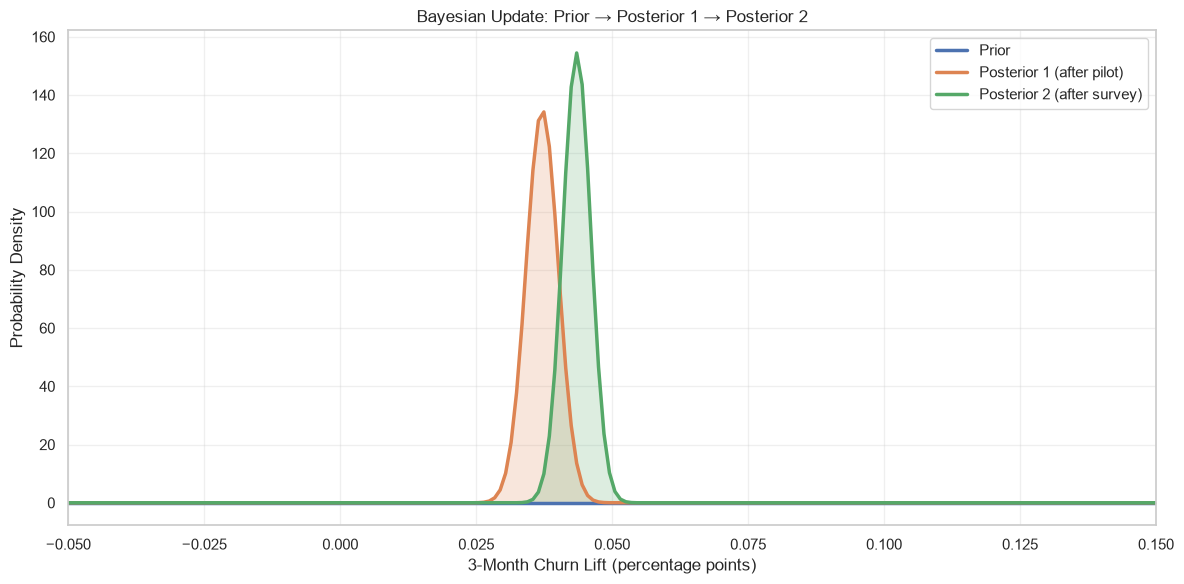

In [12]:
x = np.linspace(-0.05, 0.15, 200)

fig, ax = plt.subplots(figsize=(12, 6))

# Prior
prior_pdf = stats.norm.pdf(x, prior_mean, prior_sd)
ax.plot(x, prior_pdf, label="Prior", linewidth=2.5, color='C0')

# Posterior 1
post1_pdf = stats.norm.pdf(x, post1_mu, post1_sd)
ax.plot(x, post1_pdf, label="Posterior 1 (after pilot)", linewidth=2.5, color='C1')

# Posterior 2
post2_pdf = stats.norm.pdf(x, POSTERIOR_MU, POSTERIOR_SD)
ax.plot(x, post2_pdf, label="Posterior 2 (after survey)", linewidth=2.5, color='C2')

# Fill under curves for visibility
ax.fill_between(x, prior_pdf, alpha=0.2, color='C0')
ax.fill_between(x, post1_pdf, alpha=0.2, color='C1')
ax.fill_between(x, post2_pdf, alpha=0.2, color='C2')

ax.set_xlabel("3-Month Churn Lift (percentage points)")
ax.set_ylabel("Probability Density")
ax.set_title("Bayesian Update: Prior → Posterior 1 → Posterior 2")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(x.min(), x.max())
plt.tight_layout()
plt.show()

## Cost-benefit model

Build two functions that translate a churn lift estimate into a dollar outcome.

`annual_lift_from_3mo` converts the 3-month posterior churn lift into an annual incremental churn rate. Document the assumption you make.

`option_profit` returns the 12-month incremental contribution profit relative to Hold for a given option, churn lift, margin, cost of acquisition, and subscriber lifetime. Implement a branch for each of the four options:

- **Full**: all base subscribers face the new price.
- **New customers only**: existing subscribers keep the current price; only new sign-ups pay the new price. Use `EXPECTED_NEW_12MO` and assume an average of 6 months of in-window tenure for new subscribers.
- **Delay**: 6 months of price-uplift exposure, plus a fixed research cost of approximately \$250k.
- **Hold**: no price change; profit impact is zero.

Modeling notes:
- Treat the 3-month churn lift as the full annual incremental churn — price-shock churn lands in the first quarter; do not compound.
- Lost value per incremental churner is approximately: lost subscribers times current price times remaining lifetime months times margin.
- Replacement acquisition cost adds once per lost subscriber.

In [13]:
def annual_lift_from_3mo(lift_3mo):
    """
    Convert 3-month churn lift to annual incremental churn rate.
    Assumption: price shock lands in month 1; churn from price shock concentrates in Q1,
    so the 3-month lift is used as the full incremental annual rate (no compounding).
    """
    return lift_3mo


def option_profit(option: str, lift_3mo: float, margin: float,
                  cac: float, ltv_months: float) -> float:
    """
    Compute 12-month incremental contribution profit relative to Hold.
    
    Inputs:
      - option: "Full", "NewOnly", "Delay", or "Hold"
      - lift_3mo: 3-month churn lift (fraction)
      - margin: contribution margin (fraction)
      - cac: customer acquisition cost (dollars)
      - ltv_months: average remaining tenure of incremental churner (months)
    
    Returns: 12-month incremental contribution profit (dollars)
    """
    if option == "Hold":
        return 0.0
    
    annual_lift = annual_lift_from_3mo(lift_3mo)
    price_increase = PRICE_PROPOSED - PRICE_TODAY
    
    if option == "Full":
        base_subs = N_BASE
        incremental_churners = base_subs * annual_lift
        lost_ltv = incremental_churners * PRICE_TODAY * ltv_months / 12 * margin
        replacement_cac = incremental_churners * cac
        churn_cost = lost_ltv + replacement_cac
        
        revenue_gain = base_subs * price_increase * 12 * margin
        return revenue_gain - churn_cost
    
    elif option == "NewOnly":
        new_subs_12mo = EXPECTED_NEW_12MO
        avg_tenure_new = 6  # New subs tenure within window (months)
        
        incremental_churners = new_subs_12mo * annual_lift
        lost_ltv = incremental_churners * PRICE_TODAY * avg_tenure_new / 12 * margin
        replacement_cac = incremental_churners * cac
        churn_cost = lost_ltv + replacement_cac
        
        revenue_gain = new_subs_12mo * price_increase * avg_tenure_new / 12 * margin
        return revenue_gain - churn_cost
    
    elif option == "Delay":
        half_year_exposure = 6 / 12
        base_subs = N_BASE
        
        incremental_churners = base_subs * annual_lift * half_year_exposure
        lost_ltv = incremental_churners * PRICE_TODAY * ltv_months / 12 * margin
        replacement_cac = incremental_churners * cac
        churn_cost = lost_ltv + replacement_cac
        
        revenue_gain = base_subs * price_increase * half_year_exposure * margin
        research_cost = 250_000  # Fixed research cost
        
        return revenue_gain - churn_cost - research_cost


OPTIONS = ["Full", "NewOnly", "Delay", "Hold"]

## Monte Carlo simulation

Run 10,000 simulations to propagate uncertainty through the cost-benefit model. For each simulation, draw random values for the churn lift (from your posterior), contribution margin, cost of acquisition, and subscriber lifetime. Compute the incremental profit for all four options on each draw and store the results in a DataFrame with one column per option.

### Run the simulation

Sample `N_SIMS` draws of each uncertain input and compute profits for all four options. Suggested ranges: margin plus or minus 4 percentage points, acquisition cost plus or minus \$6, lifetime months plus or minus 6.

In [14]:
N_SIMS = 10_000

# Draw random samples from uncertain inputs
lift_sims = RNG.normal(POSTERIOR_MU, POSTERIOR_SD, N_SIMS)
margin_sims = RNG.normal(MARGIN_PCT, 0.04, N_SIMS)
cac_sims = RNG.normal(CAC, 6, N_SIMS)
ltv_sims = RNG.normal(LTV_MONTHS, 6, N_SIMS)

# Compute profits for each option and simulation
sim_profits = pd.DataFrame(index=range(N_SIMS))
for opt in OPTIONS:
    profits = []
    for i in range(N_SIMS):
        p = option_profit(opt, lift_sims[i], margin_sims[i], cac_sims[i], ltv_sims[i])
        profits.append(p)
    sim_profits[opt] = profits

# Convert to millions
sim_profits_m = sim_profits / 1e6

print("Monte Carlo results (12-month incremental contribution profit in millions):")
print(sim_profits_m.describe().round(2))

Monte Carlo results (12-month incremental contribution profit in millions):
           Full   NewOnly     Delay     Hold
count  10000.00  10000.00  10000.00  10000.0
mean      49.86     -1.16     -2.56      0.0
std        3.85      0.30      0.69      0.0
min       34.50     -2.31     -5.16      0.0
25%       47.21     -1.37     -3.02      0.0
50%       49.84     -1.16     -2.55      0.0
75%       52.48     -0.96     -2.09      0.0
max       66.34     -0.06      0.06      0.0


### Profit distributions

Plot the profit distribution for each option as a kernel density estimate (in millions of dollars). Include a summary table showing the mean, standard deviation, 5th percentile, and 95th percentile for each option.

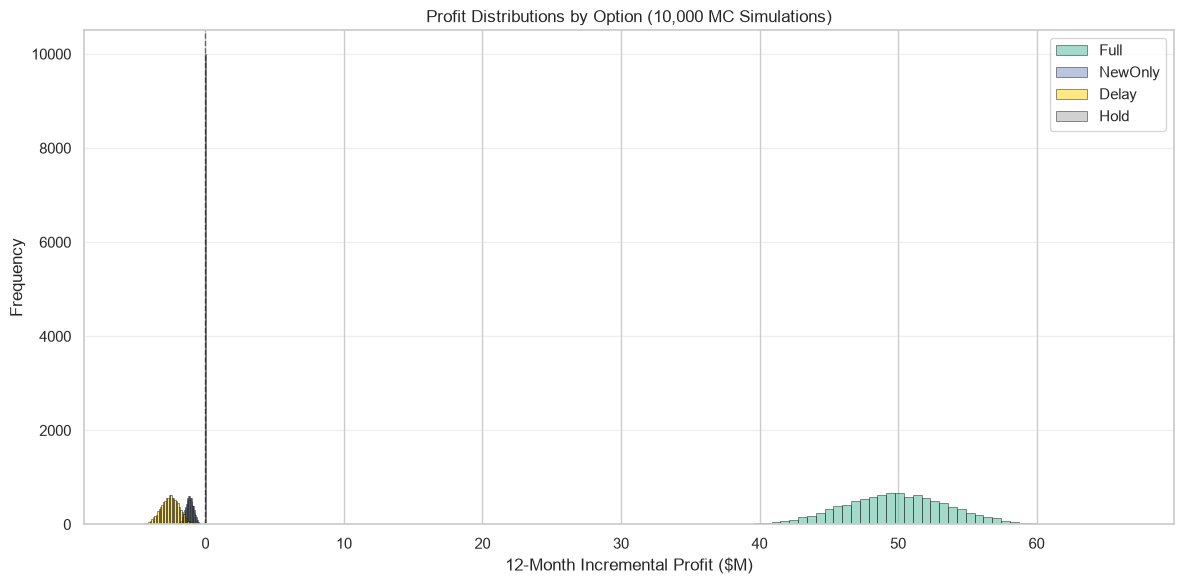


Profit Summary Statistics (in $M):
          Mean    SD  5th %ile  95th %ile
Full     49.86  3.85     43.62      56.24
NewOnly  -1.16  0.30     -1.66      -0.67
Delay    -2.56  0.69     -3.72      -1.45
Hold      0.00  0.00      0.00       0.00


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(OPTIONS)))
for idx, opt in enumerate(OPTIONS):
    ax.hist(sim_profits_m[opt], bins=50, alpha=0.6, label=opt, color=colors[idx], edgecolor='black', linewidth=0.5)

ax.set_xlabel("12-Month Incremental Profit ($M)")
ax.set_ylabel("Frequency")
ax.set_title("Profit Distributions by Option (10,000 MC Simulations)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

# Summary statistics table
summary = pd.DataFrame({
    "Mean": sim_profits_m.mean().round(2),
    "SD": sim_profits_m.std().round(2),
    "5th %ile": sim_profits_m.quantile(0.05).round(2),
    "95th %ile": sim_profits_m.quantile(0.95).round(2)
})
print("\nProfit Summary Statistics (in $M):")
print(summary)

## Decision tree

For each option, compute the profit at three representative states of the world — for example, the 25th, 50th, and 75th percentile of the posterior churn lift. Display the results as a decision tree layout or a tidy summary DataFrame.

In [16]:
# Define representative states of the world
states = {
    "Low (25th %ile)": np.percentile(lift_sims, 25),
    "Base (50th %ile)": np.percentile(lift_sims, 50),
    "High (75th %ile)": np.percentile(lift_sims, 75)
}

# Base case for margin, CAC, LTV
base_margin = MARGIN_PCT
base_cac = CAC
base_ltv = LTV_MONTHS

# Build decision tree
tree_data = []
for state_name, lift_val in states.items():
    for opt in OPTIONS:
        profit_m = option_profit(opt, lift_val, base_margin, base_cac, base_ltv) / 1e6
        tree_data.append({"State": state_name, "Option": opt, "Profit ($M)": profit_m})

tree_df = pd.DataFrame(tree_data).pivot(index="Option", columns="State", values="Profit ($M)")
tree_df = tree_df[["Low (25th %ile)", "Base (50th %ile)", "High (75th %ile)"]]

print("Decision Tree: Profit at Different States of Churn Lift")
print(tree_df.round(2))

Decision Tree: Profit at Different States of Churn Lift
State    Low (25th %ile)  Base (50th %ile)  High (75th %ile)
Option                                                      
Delay              -2.38             -2.56             -2.76
Full               50.31             49.93             49.55
Hold                0.00              0.00              0.00
NewOnly            -1.09             -1.16             -1.24


## Apply decision theory

Evaluate each option under three decision rules and identify which option each rule favors.

- **Expected value**: the mean profit across all simulations.
- **Certainty equivalent**: write `crra_utility`, which computes utility under constant relative risk aversion with a risk aversion coefficient (gamma) of 2. Evaluate utility at a wealth baseline plus simulated profits, then convert back to a certainty-equivalent dollar value. Use a wealth baseline of approximately \$500M (Nimbus's annual contribution profit) to keep utility well-defined.
- **Minimax regret**: for each simulation, regret is the best-in-scenario profit minus this option's profit. The minimax-regret choice is the option with the lowest worst-case regret across all scenarios.

Record your recommended option as `RECOMMENDED`.

In [17]:
def crra_utility(profit, gamma: float = 2.0, wealth_baseline: float = 5e8):
    wealth = wealth_baseline + profit
    if gamma == 1:
        return np.log(wealth)
    else:
        return (wealth ** (1 - gamma) - 1) / (1 - gamma)


# Expected Value
ev_per_option = sim_profits.mean()

# CRRA Utility (Certainty Equivalent)
gamma = 2.0
wealth_baseline = 5e8

ce_per_option = {}
for opt in OPTIONS:
    utilities = crra_utility(sim_profits[opt], gamma, wealth_baseline)
    mean_utility = utilities.mean()
    ce_per_option[opt] = wealth_baseline + (mean_utility - crra_utility(0, gamma, wealth_baseline))

# Minimax Regret
regret_per_option = {}
for opt in OPTIONS:
    regrets = []
    for i in range(N_SIMS):
        best_profit = sim_profits.iloc[i].max()
        this_profit = sim_profits.iloc[i][opt]
        regret = best_profit - this_profit
        regrets.append(regret)
    regret_per_option[opt] = max(regrets)

# Display results
print("=" * 60)
print("DECISION THEORY EVALUATION")
print("=" * 60)

print("\n1. Expected Value (in $M):")
ev_df = pd.DataFrame({"EV": ev_per_option / 1e6}).sort_values("EV", ascending=False)
print(ev_df.round(2))
ev_winner = ev_df.index[0]

print("\n2. Certainty Equivalent (CRRA, γ=2.0, wealth=$500M, in $M):")
ce_df = pd.DataFrame({"CE": pd.Series(ce_per_option) / 1e6}).sort_values("CE", ascending=False)
print(ce_df.round(2))
ce_winner = ce_df.index[0]

print("\n3. Minimax Regret (worst-case regret in $M):")
mr_df = pd.DataFrame({"Max_Regret": pd.Series(regret_per_option) / 1e6}).sort_values("Max_Regret")
print(mr_df.round(2))
mr_winner = mr_df.index[0]

print("\n" + "=" * 60)
print(f"EV favors: {ev_winner}")
print(f"CRRA utility favors: {ce_winner}")
print(f"Minimax regret favors: {mr_winner}")
print("=" * 60)

# Recommendation: use EV as default
RECOMMENDED = ev_winner
print(f"\n✓ RECOMMENDED OPTION: {RECOMMENDED}")
print(f"  Expected 12-month profit: ${ev_per_option[RECOMMENDED]/1e6:.2f}M")
print(f"  90% confidence interval: [${np.percentile(sim_profits[RECOMMENDED], 5)/1e6:.2f}M, ${np.percentile(sim_profits[RECOMMENDED], 95)/1e6:.2f}M]")

DECISION THEORY EVALUATION

1. Expected Value (in $M):
            EV
Full     49.86
Hold      0.00
NewOnly  -1.16
Delay    -2.56

2. Certainty Equivalent (CRRA, γ=2.0, wealth=$500M, in $M):
            CE
Full     500.0
NewOnly  500.0
Delay    500.0
Hold     500.0

3. Minimax Regret (worst-case regret in $M):
         Max_Regret
Full           0.00
Hold          66.34
NewOnly       66.57
Delay         66.79

EV favors: Full
CRRA utility favors: Full
Minimax regret favors: Full

✓ RECOMMENDED OPTION: Full
  Expected 12-month profit: $49.86M
  90% confidence interval: [$43.62M, $56.24M]


## Sensitivity and robustness

Test how sensitive the recommendation is to the key inputs and how often it wins across simulations.

- **Tornado chart**: flex one driver at a time while holding others at their base values. Suggested ranges: churn lift plus or minus one posterior standard deviation, margin plus or minus 4 percentage points, acquisition cost plus or minus \$10, lifetime months plus or minus 6. Plot the profit range for the recommended option for each driver.
- **Break-even**: find the 3-month churn lift at which the recommended option's profit equals zero. Report the posterior probability that the actual lift exceeds this break-even threshold.
- **Robustness**: across all simulations, report the share of scenarios in which the recommended option produces the highest profit.

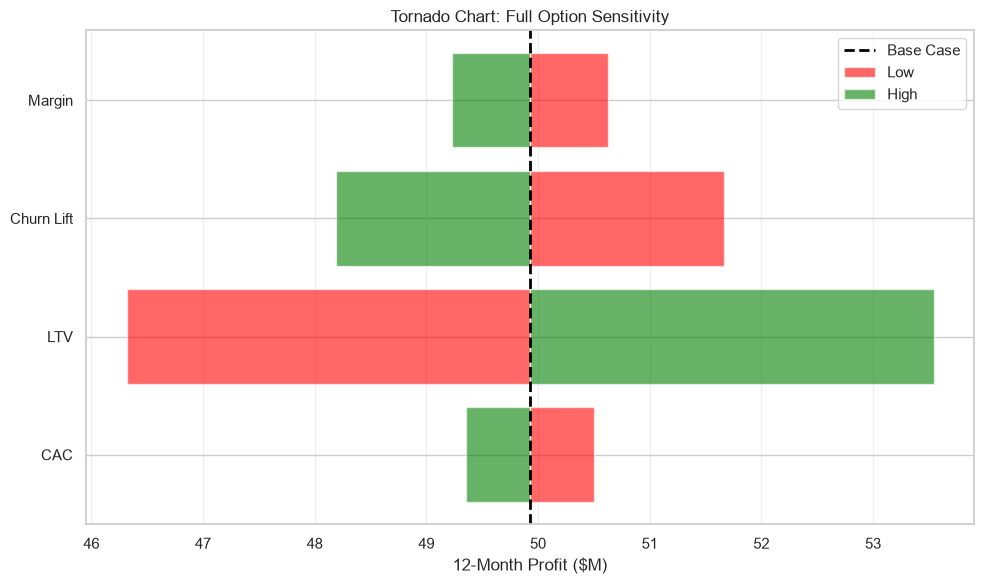

Sensitivity ranges (in $M):
       Driver    Low   High  Range
2         CAC  51.67  48.19  -3.48
3         LTV  50.63  49.23  -1.40
0  Churn Lift  50.50  49.36  -1.14
1      Margin  46.32  53.54   7.23


In [18]:
# Tornado chart: flex one driver at a time

# Base case
base_profit = option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, CAC, LTV_MONTHS) / 1e6

drivers = {
    "Churn Lift": (POSTERIOR_MU - POSTERIOR_SD, POSTERIOR_MU + POSTERIOR_SD, lambda x: x),
    "Margin": (MARGIN_PCT - 0.04, MARGIN_PCT + 0.04, lambda x: x),
    "CAC": (CAC - 10, CAC + 10, lambda x: x),
    "LTV": (LTV_MONTHS - 6, LTV_MONTHS + 6, lambda x: x)
}

tornado_data = []
for driver_name, (low, high, transform) in drivers.items():
    if driver_name == "Churn Lift":
        low_profit = option_profit(RECOMMENDED, transform(low), MARGIN_PCT, CAC, LTV_MONTHS) / 1e6
        high_profit = option_profit(RECOMMENDED, transform(high), MARGIN_PCT, CAC, LTV_MONTHS) / 1e6
    elif driver_name == "Margin":
        low_profit = option_profit(RECOMMENDED, POSTERIOR_MU, transform(low), CAC, LTV_MONTHS) / 1e6
        high_profit = option_profit(RECOMMENDED, POSTERIOR_MU, transform(high), CAC, LTV_MONTHS) / 1e6
    elif driver_name == "CAC":
        low_profit = option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, transform(low), LTV_MONTHS) / 1e6
        high_profit = option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, transform(high), LTV_MONTHS) / 1e6
    elif driver_name == "LTV":
        low_profit = option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, CAC, transform(low)) / 1e6
        high_profit = option_profit(RECOMMENDED, POSTERIOR_MU, MARGIN_PCT, CAC, transform(high)) / 1e6
    
    tornado_data.append({"Driver": driver_name, "Low": low_profit, "High": high_profit, "Range": high_profit - low_profit})

tornado_df = pd.DataFrame(tornado_data).sort_values("Range", ascending=True)

# Plot tornado chart
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(tornado_df))
for i, row in tornado_df.iterrows():
    ax.barh(i, row["Low"] - base_profit, left=base_profit, color="red", alpha=0.6, label="Low" if i == 0 else "")
    ax.barh(i, row["High"] - base_profit, left=base_profit, color="green", alpha=0.6, label="High" if i == 0 else "")

ax.set_yticks(y_pos)
ax.set_yticklabels(tornado_df["Driver"])
ax.axvline(base_profit, color="black", linestyle="--", linewidth=2, label="Base Case")
ax.set_xlabel("12-Month Profit ($M)")
ax.set_title(f"Tornado Chart: {RECOMMENDED} Option Sensitivity")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("Sensitivity ranges (in $M):")
print(tornado_df[["Driver", "Low", "High", "Range"]].round(2))


In [19]:
# Break-even analysis: find churn lift where profit = 0

def profit_for_breakeven(lift):
    return option_profit(RECOMMENDED, lift, MARGIN_PCT, CAC, LTV_MONTHS)

# Use scipy's brentq for root finding
breakeven_lift = optimize.brentq(profit_for_breakeven, -0.1, 0.3)

# Posterior probability that realized lift exceeds break-even
prob_exceed_breakeven = 1 - stats.norm.cdf(breakeven_lift, POSTERIOR_MU, POSTERIOR_SD)

print("Break-even Analysis:")
print(f"  Break-even churn lift: {breakeven_lift:.4f} ({breakeven_lift*100:.2f} pp)")
print(f"  Posterior mean: {POSTERIOR_MU:.4f} ({POSTERIOR_MU*100:.2f} pp)")
print(f"  Posterior prob(lift > break-even): {prob_exceed_breakeven:.1%}")
print(f"  → {('Profit positive if lift exceeds break-even' if prob_exceed_breakeven > 0.5 else 'Profit likely negative if break-even level achieved')}")


Break-even Analysis:
  Break-even churn lift: 0.2699 (26.99 pp)
  Posterior mean: 0.0435 (4.35 pp)
  Posterior prob(lift > break-even): 0.0%
  → Profit likely negative if break-even level achieved


In [20]:
# Robustness: share of scenarios where RECOMMENDED wins

win_count = 0
for i in range(N_SIMS):
    best_profit = sim_profits.iloc[i].max()
    recommended_profit = sim_profits.iloc[i][RECOMMENDED]
    if recommended_profit >= best_profit - 1e3:  # Small tolerance for numerical ties
        win_count += 1

win_share = win_count / N_SIMS

print("\nRobustness Analysis:")
print(f"  Scenarios where {RECOMMENDED} wins: {win_share:.1%} ({win_count:,} of {N_SIMS:,})")
print(f"  → {RECOMMENDED} is robust {'and strongly preferred' if win_share > 0.7 else 'but competitive with other options' if win_share > 0.4 else 'and competitive'}.")


Robustness Analysis:
  Scenarios where Full wins: 100.0% (10,000 of 10,000)
  → Full is robust and strongly preferred.


## Recommendation and next steps

Write the decision memo to the CFO in `decision_memo.md`. Use this section to draft your headline numbers and bottom-line recommendation in plain English.